# IMPORTANDO DADOS

In [23]:
# ===== CÉLULA 1: IMPORTAÇÃO DE BIBLIOTECAS =====

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

# AQUI É CONFIGURAD0 AS PALETAS E O ESTILO DOS GRÁFICOS
plt.style.use('ggplot')
sns.set_palette("husl")

 # COMANDO "MÁGICO" QUE FAZ COM QUE O GRÁFICO SEJA APRESENTADO DIRETAMENTE NO NOTEBOOK
%matplotlib inline

In [24]:
# ===== CÉLULA 2: CARREGANDO DATABASE =====

from google.colab import files

# UPLOAD DO ARQUIVO ENCONTRADO ATRAVÉS DE PESQUISA
# SITE USADO: 'https://www.kaggle.com/datasets/jimschacko/airlines-dataset-to-predict-a-delay?resource=download'
uploaded = files.upload()

# DEFININDO A VARIÁVEL COM O ARQUIVO .csv USANDO TRATATIVA DE DADOS
# encoding='utf-8'--> DEFINE CONDIÇÃO CORRETA DE CARACTERES (ç, ã, é)
# sep=','--> DEFINE O SEPARADOR DAS COLUNAS
df = pd.read_csv('Airlines.csv', encoding='utf-8', sep=',')

# VIZUALIZAÇÃO DO ARQUIVO CARREGADO
print("✅ DATASET DE VOOS CARREGADOS")
print(f"📊 DIMENSÃO: {df.shape[0]} LINHAS x {df.shape[1]} COLUNAS")

Saving Airlines.csv to Airlines (1).csv
✅ DATASET DE VOOS CARREGADOS
📊 DIMENSÃO: 539383 LINHAS x 9 COLUNAS


---

# 📌 RESUMO DO DATASET CARREGADO

## ✅ Checklist Inicial
- **Dataset:** Airlines (Kaggle)
- **Total de registros:** 539.383 voos
- **Total de variáveis:** 9 colunas
- **Período:** Dados históricos de voos comerciais
- **Objetivo:** Prever atrasos de voos (classificação binária)

## 🎯 Variável-Alvo
- **Coluna:** `Delay`
- **Tipo:** Binária (0 = Sem atraso, 1 = Com atraso)
- **Distribuição:** 44,54% de voos atrasados (relativamente balanceada)

---


In [25]:
# ===== CÉLULA 3: VISÃO GERAL DA ESTRUTURA =====

# DIMENSÃO
print("=" * 25)
print("📐 DIMENSÃO DO DATASET")
print("=" * 25)
print(f"LINHAS (REGISTROS): {df.shape[0]}")
print(f"COLUANS (VARIAVÉIS): {df.shape[1]}")

# AMOSTRA - INÍCIO
print("\n" + "=" * 25)
print("👀 PRIMEIRAS 5 LINHAS")
print("=" * 25)
# AQUI UTILIZO O DISPLAY AO INVÉS DO 'print' PARA FORMATAR A SAÍDA DOS DADOS
display(df.head()) # MOSTRA AS PRIMEIRAS 5 LINHAS DO DATASET

# AMOSTRA - FIM
print("\n" + "=" * 25)
print("👀 ÚLTIMAS 5 LINHAS")
print("=" * 25)
display(df.tail()) # MOSTRA AS ÚLTIMAS 5 LINHAS DO DATASET

# INFORMAÇÕES GERAIS
print("\n" + "=" * 40)
print("🔍 TIPOS DE DADOS E VALORES NULOS")
print("=" * 40)
df.info() # MOSTRA OS TIPOS DE DADOS ENCONTRADOS E SE HÁ VALORES NULOS


📐 DIMENSÃO DO DATASET
LINHAS (REGISTROS): 539383
COLUANS (VARIAVÉIS): 9

👀 PRIMEIRAS 5 LINHAS


,id,Airline,Flight,AirportFrom,AirportTo,DayOfWeek,Time,Length,Delay
0,1,CO,269,SFO,IAH,3,15,205,1
1,2,US,1558,PHX,CLT,3,15,222,1
2,3,AA,2400,LAX,DFW,3,20,165,1
3,4,AA,2466,SFO,DFW,3,20,195,1
4,5,AS,108,ANC,SEA,3,30,202,0



👀 ÚLTIMAS 5 LINHAS


,id,Airline,Flight,AirportFrom,AirportTo,DayOfWeek,Time,Length,Delay
539378,539379,CO,178,OGG,SNA,5,1439,326,0
539379,539380,FL,398,SEA,ATL,5,1439,305,0
539380,539381,FL,609,SFO,MKE,5,1439,255,0
539381,539382,UA,78,HNL,SFO,5,1439,313,1
539382,539383,US,1442,LAX,PHL,5,1439,301,1



🔍 TIPOS DE DADOS E VALORES NULOS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 539383 entries, 0 to 539382
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   id           539383 non-null  int64 
 1   Airline      539383 non-null  object
 2   Flight       539383 non-null  int64 
 3   AirportFrom  539383 non-null  object
 4   AirportTo    539383 non-null  object
 5   DayOfWeek    539383 non-null  int64 
 6   Time         539383 non-null  int64 
 7   Length       539383 non-null  int64 
 8   Delay        539383 non-null  int64 
dtypes: int64(6), object(3)
memory usage: 37.0+ MB


In [26]:
# ===== CÉLULA 4: CLASSIFICAÇÃO DAS COLUNAS POR TIPO =====

# COLUNAS NUMÉRICAS
colunas_numericas = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
# 'df.select_dtypes' --> SELECIONA COLUNAS POR TIPOS
# TIPOS SOLICITADOS --> 'int64' E 'float64'
# '.columns' --> PEGA APENAS OS NOMES DAS COLUNAS
# '.tolist()' --> CONVERSÇÃO PARA UMA LISTA PYTHON
print("=" * 25)
print("🔢 COLUNAS NUMÉRICAS")
print("=" * 25)
print(f"Total: {len(colunas_numericas)} colunas\n")
print(colunas_numericas)

# COLUNAS CATEGÓRICAS
colunas_categoricas = df.select_dtypes(include=['object', 'category']).columns.tolist()
# 'df.select_dtypes' --> SELECIONA COLUNAS POR TIPOS
# TIPOS SOLICITADOS --> 'object' E 'category'
# '.columns' --> PEGA APENAS OS NOMES DAS COLUNAS
# '.tolist()' --> CONVERSÇÃO PARA UMA LISTA PYTHON
print("\n" + "=" * 25)
print("📝 COLUNAS CATEGÓRICAS")
print("=" * 25)
print(f"Total: {len(colunas_categoricas)} colunas\n")
print(colunas_categoricas)

# TABELA RESUMO
resumo_colunas = pd.DataFrame({
    'COLUNA': df.columns, # NOME DE CADA COLUNA
    'TIPO': df.dtypes.values, # TIPO DE DADO (int64,object,float...)
    'NÃO-NULOS': df.count().values, # QUANTIDADE DE VALORES NÃO-NULOS
    'NULOS': df.isnull().sum().values, # QUANTIDADE DE VALORES NULOS
    # LOOP SIMPLIFICADO QUE PEGA O PRIMEIRO VALOR DE CADA COLUNA E MOSTRA NA SAÍDA
    'EXEMPLO': [df[col].iloc[0] for col in df.columns]
})
print("\n" + "=" * 30)
print("📊 RESUMO COMPLETO DAS COLUNAS")
print("=" * 30)
display(resumo_colunas)

# VALIDAÇÃO MANUAL
print("\n" + "=" * 25)
print("⚠️ VALIDAÇÃO DE TIPOS")
print("=" * 25)
print("\n📌VALORES ÚNICOS 'DayOfWeek':")
# 'unique0'--> MOSTRA TODOS OS VALORES ÚNICOSNA COLUNA
print(df['DayOfWeek'].unique())
# '.nunique'--> CONTA QUANTOS VALORES ÚNICOS TEM
print(f"TOTAL: {df['DayOfWeek'].nunique()} VALORES ÚNICOS")

# RECLASSIFICAÇÃO
# É EXECUTADA QUANDO A COLUNA 'id' FOR CLASSIFICADA COMO NÚMERICA
if 'id' in colunas_numericas:
    colunas_numericas.remove('id') # REMOVE QUANDO A CINDICONAL FOR VERDADEIRA
    print("\n✅ 'id' REMOVIDO DAS NÚMERICAS")

# LISTAS FINAIS
print("\n" + "=" * 25)
print("📋 CLASSIFICAÇÃO FINAL")
print("=" * 25)
#CONTAGEM E EXIBIÇÃO DE COLUNAS NÚMERICAS
print(f"\n🔢 NÚMERICAS ({len(colunas_numericas)}): {colunas_numericas}")
#CONTAGEM E EXIBIÇÃO DE COLUNAS CATEGÓRICAS
print(f"\n📝 CATEGÓRICAS ({len(colunas_categoricas)}): {colunas_categoricas}")


🔢 COLUNAS NUMÉRICAS
Total: 6 colunas

['id', 'Flight', 'DayOfWeek', 'Time', 'Length', 'Delay']

📝 COLUNAS CATEGÓRICAS
Total: 3 colunas

['Airline', 'AirportFrom', 'AirportTo']

📊 RESUMO COMPLETO DAS COLUNAS


,COLUNA,TIPO,NÃO-NULOS,NULOS,EXEMPLO
0,id,int64,539383,0,1
1,Airline,object,539383,0,CO
2,Flight,int64,539383,0,269
3,AirportFrom,object,539383,0,SFO
4,AirportTo,object,539383,0,IAH
5,DayOfWeek,int64,539383,0,3
6,Time,int64,539383,0,15
7,Length,int64,539383,0,205
8,Delay,int64,539383,0,1



⚠️ VALIDAÇÃO DE TIPOS

📌VALORES ÚNICOS 'DayOfWeek':
[3 4 5 6 7 1 2]
TOTAL: 7 VALORES ÚNICOS

✅ 'id' REMOVIDO DAS NÚMERICAS

📋 CLASSIFICAÇÃO FINAL

🔢 NÚMERICAS (5): ['Flight', 'DayOfWeek', 'Time', 'Length', 'Delay']

📝 CATEGÓRICAS (3): ['Airline', 'AirportFrom', 'AirportTo']


---

## 🔍 INSIGHTS: ESTRUTURA DOS DADOS

### ✅ Qualidade do Dataset
1. **Nenhum valor ausente** identificado (0% de nulos em todas as colunas)
2. Dataset **completo e limpo** — pronto para análise
3. Total de **539.383 registros** válidos em todas as variáveis

### 📊 Classificação das Variáveis

| Tipo | Variáveis | Observação |
|------|-----------|------------|
| **Numéricas** | `Flight`, `DayOfWeek`, `Time`, `Length` | Excluído `id` (apenas identificador) |
| **Categóricas** | `Airline`, `AirportFrom`, `AirportTo` | 15 companhias e 291 aeroportos |
| **Alvo** | `Delay` | Binária (0/1) |

### ⚠️ Anomalias Identificadas

1. **Coluna `id`:**
   - Classificada como numérica, mas **sem significado estatístico**
   - **Ação tomada:** Removida da lista de variáveis numéricas
   - Não será usada em modelos futuros

2. **Coluna `Length`:**
   - Valor mínimo = **0 minutos** (voos de duração zero?)
   - **Hipótese:** Possível erro de registro ou voos cancelados
   - **Ação futura:** Investigar registros com `Length = 0`

---


In [27]:
# ===== CÉLULA 5: ANÁLISE DE VALORES NULOS (Nan,NULL,None) =====

# '.isnull()' --> VERIFICA CADA CÉLULA, RETORNA 'True' SE NULA E 'False' SE NÃO
# '.sum()' --> CONTA QUANTOS 'True' EXISTEM
nulos_absolutos = df.isnull().sum()
nulos_percentual = (df.isnull().sum() / len(df)) * 100

# CONTAGEM DE VALORES NULOS
print("=" * 20)
print("🔍 VALORES NULOS")
print("=" * 20)
print(nulos_absolutos)
print("\n")

# CONTAGEM DA PORCENTAGEM DE VALORES NULOS
print("=" * 30)
print("📊 VALORES NULOS - PERCENTUAL")
print("=" * 30)
print(nulos_percentual)
print("\n")

resumo_nulos = pd.DataFrame({
    'COLUNA': df.columns,
    'NULOS': df.isnull().sum().values,
    'PERCENTUAL(%)': nulos_percentual.values,
    'TIPO': df.dtypes.values
})

# ORDENAR DA COLUNA COM MAIS NULOS PARA MEOS NULOS
# ascending=False --> ORDEM DECRESCENTE (MAIOR PRIMEIRO)
# ascending=True --> ORDEM CRESCENTE (MENOR PRIMEIRO)
resumo_nulos = resumo_nulos.sort_values(by='PERCENTUAL(%)', ascending=False)

print("=" * 50)
print("📋 RESUMO COMPLETO - VALORES AUSENTES")
print("=" * 50)
display(resumo_nulos)

# EXIBIR APENAS COLUNAS COM VALORES FALTANTES
colunas_com_nulos = resumo_nulos[resumo_nulos['NULOS'] > 0]

# CONDICIONAL PARA EXIBIR APENAS A COLUNA COM VALORES NULOS
if len(colunas_com_nulos) > 0:
    print("\n" + "=" * 60)
    print("⚠️ COLUNAS COM VALORES AUSENTES")
    print("=" * 60)
    display(colunas_com_nulos)

# CASO NÃO HAJA VALORES NULOS, EXIBIR MENSAGEM ABAIXO
else:
    print("\n✅ NENHUM VALOR AUSENTE ENCONTRADO!")

🔍 VALORES NULOS
id             0
Airline        0
Flight         0
AirportFrom    0
AirportTo      0
DayOfWeek      0
Time           0
Length         0
Delay          0
dtype: int64


📊 VALORES NULOS - PERCENTUAL
id             0.0
Airline        0.0
Flight         0.0
AirportFrom    0.0
AirportTo      0.0
DayOfWeek      0.0
Time           0.0
Length         0.0
Delay          0.0
dtype: float64


📋 RESUMO COMPLETO - VALORES AUSENTES


,COLUNA,NULOS,PERCENTUAL(%),TIPO
0,id,0,0.0,int64
1,Airline,0,0.0,object
2,Flight,0,0.0,int64
3,AirportFrom,0,0.0,object
4,AirportTo,0,0.0,object
5,DayOfWeek,0,0.0,int64
6,Time,0,0.0,int64
7,Length,0,0.0,int64
8,Delay,0,0.0,int64



✅ NENHUM VALOR AUSENTE ENCONTRADO!


In [28]:
# ===== CÉLULA 6: ESTÁTISTICAS DESCRITIVAS DETALHADAS =====

# ESTATÍSTICAS BÁSICAS
print("=" * 50)
print("📊 ESTATÍSTICAS DESCRITIVAS - VARIÁVEIS NUMÉRICAS")
print("=" * 50)

# 'df.describe()' --> USADO PARA CALCULAR 8 MÉTRICAS ESTÁTISTICAS
# '.T' --> USADO PARA TRANSPOR A TABELA (LINHAS VIRAM COLUNAS)
display(df.describe().T)

# MÉTRICAS COMPLEMENTARES
print("\n" + "=" * 50)
print("📈 MÉTRICAS ESTATÍSTICAS ADICIONAIS")
print("=" * 50)

colunas_analise = [col for col in colunas_numericas if col != 'id']

for col in colunas_analise:
    print(f"\n{'='*50}")
    print(f"📊 COLUNA: {col}")
    print(f"{'='*50}")

    # MÉTRICA PARA MEDIR AMPLITUDE: 'df[col].max()' e 'df[col].min()'
    amplitude = df[col].max() - df[col].min()
    # MÉTRICA PARA MEDIR ASSIMETRIA: '.skew'
    assimetria = df[col].skew()
    # MÉTODO PARA MEDIR O ACHATAMENTO OU PICO: '.kurtosis'
    curtose = df[col].kurtosis()
    # LÓGICA PARA MEDIR O COEFICIENTE DE VARIAÇÃO
    # A LÓGICA PARA MEDIR O CV É: 'CV = (DESVIO-PADRÃO / MÉDIA) × 100'
    cv = (df[col].std() / df[col].mean()) * 100 if df[col].mean() != 0 else 0

    print(f"AMPLITUDE:              {amplitude:.2f}")
    print(f"ASSIMETRIA:             {assimetria:.3f}")
    print(f"CURTOSE:                {curtose:.3f}")
    print(f"COEFICIENTE DE VARIAÇÃO:{cv:.2f}%")

    # CONDICIONAL PARA DEFINIR A ASSIMETRIA
    if assimetria > 0.5:
        print("DISTRIBUIÇÃO ASSIMÉTRICA À DIREITA")
    elif assimetria < -0.5:
        print("DISTRIBUIÇÃO ASSIMÉTRICA À ESQUERDA")
    else:
        print("DISTRIBUIÇÃO APROXIMADAMENTE SIMÉTRICA")

# TABELA RESUMO
print("\n" + "=" * 70)
print("📋 TABELA RESUMO - TODAS AS MÉTRICAS")
print("=" * 70)

resumo_estatisticas = pd.DataFrame({
    'COLUNA': colunas_analise,
    'MÉDIA': [df[col].mean() for col in colunas_analise],
    'MEDIANA': [df[col].median() for col in colunas_analise],
    'DESVIO PADRÃO': [df[col].std() for col in colunas_analise],
    'MÍNIMO': [df[col].min() for col in colunas_analise],
    'MÁXIMO': [df[col].max() for col in colunas_analise],
    'AMPLITUDE': [df[col].max() - df[col].min() for col in colunas_analise],
    'ASSIMETRIA': [df[col].skew() for col in colunas_analise],
    'CURTOSE': [df[col].kurtosis() for col in colunas_analise]
}).round(2)

display(resumo_estatisticas)

# ANÁLISE CATEGÓRICAS
print("\n\n" + "=" * 50)
print("📝 ANÁLISE DE VARIÁVEIS CATEGÓRICAS")
print("=" * 50)

for col in colunas_categoricas:
    print(f"\n{'='*50}")
    print(f"📌 COLUNA: {col}")
    print(f"{'='*50}")

    # '.nunique'--> CONTAGEM DE CATEGORIAS ÚNICAS
    n_unicos = df[col].nunique()
    print(f"TOTAL DE CATEGORIAS ÚNICAS: {n_unicos}")

    frequencias = df[col].value_counts()
    percentuais = df[col].value_counts(normalize=True) * 100

    tabela_freq = pd.DataFrame({
        'CATEGORIA': frequencias.index,
        'FREQUENCIA': frequencias.values,
        'PERCENTUAL (%)': percentuais.values.round(2)
    })

    print("\nTOP 10 CATEGORIAS MAIS FREQUENTES")
    #USADO PARA VERIFICAR AS 10 CATEGORIAS
    display(tabela_freq.head(10))

    # USADO PARA VERIFICAR A CATEGORIA QUE MAIS APARECE NO DATASET
    moda = df[col].mode()[0]
    print(f"\nCATEGORIA MAIS COMUM: {moda}")


📊 ESTATÍSTICAS DESCRITIVAS - VARIÁVEIS NUMÉRICAS


,count,mean,std,min,25%,50%,75%,max
id,539383.0,269692.000000,155706.604460,1.0,134846.5,269692.0,404537.5,539383.0
Flight,539383.0,2427.928630,2067.429837,1.0,712.0,1809.0,3745.0,7814.0
DayOfWeek,539383.0,3.929668,1.914664,1.0,2.0,4.0,5.0,7.0
Time,539383.0,802.728963,278.045911,10.0,565.0,795.0,1035.0,1439.0
Length,539383.0,132.202007,70.117016,0.0,81.0,115.0,162.0,655.0
Delay,539383.0,0.445442,0.497015,0.0,0.0,0.0,1.0,1.0



📈 MÉTRICAS ESTATÍSTICAS ADICIONAIS

📊 COLUNA: Flight
AMPLITUDE:              7813.00
ASSIMETRIA:             0.869
CURTOSE:                -0.357
COEFICIENTE DE VARIAÇÃO:85.15%
DISTRIBUIÇÃO ASSIMÉTRICA À DIREITA

📊 COLUNA: DayOfWeek
AMPLITUDE:              6.00
ASSIMETRIA:             0.062
CURTOSE:                -1.093
COEFICIENTE DE VARIAÇÃO:48.72%
DISTRIBUIÇÃO APROXIMADAMENTE SIMÉTRICA

📊 COLUNA: Time
AMPLITUDE:              1429.00
ASSIMETRIA:             0.076
CURTOSE:                -1.015
COEFICIENTE DE VARIAÇÃO:34.64%
DISTRIBUIÇÃO APROXIMADAMENTE SIMÉTRICA

📊 COLUNA: Length
AMPLITUDE:              655.00
ASSIMETRIA:             1.494
CURTOSE:                2.757
COEFICIENTE DE VARIAÇÃO:53.04%
DISTRIBUIÇÃO ASSIMÉTRICA À DIREITA

📊 COLUNA: Delay
AMPLITUDE:              1.00
ASSIMETRIA:             0.220
CURTOSE:                -1.952
COEFICIENTE DE VARIAÇÃO:111.58%
DISTRIBUIÇÃO APROXIMADAMENTE SIMÉTRICA

📋 TABELA RESUMO - TODAS AS MÉTRICAS


,COLUNA,MÉDIA,MEDIANA,DESVIO PADRÃO,MÍNIMO,MÁXIMO,AMPLITUDE,ASSIMETRIA,CURTOSE
0,Flight,2427.93,1809.0,2067.43,1,7814,7813,0.87,-0.36
1,DayOfWeek,3.93,4.0,1.91,1,7,6,0.06,-1.09
2,Time,802.73,795.0,278.05,10,1439,1429,0.08,-1.01
3,Length,132.20,115.0,70.12,0,655,655,1.49,2.76
4,Delay,0.45,0.0,0.50,0,1,1,0.22,-1.95




📝 ANÁLISE DE VARIÁVEIS CATEGÓRICAS

📌 COLUNA: Airline
TOTAL DE CATEGORIAS ÚNICAS: 18

TOP 10 CATEGORIAS MAIS FREQUENTES


...


CATEGORIA MAIS COMUM: WN

📌 COLUNA: AirportFrom
TOTAL DE CATEGORIAS ÚNICAS: 293

TOP 10 CATEGORIAS MAIS FREQUENTES


,CATEGORIA,FREQUENCIA,PERCENTUAL (%)
0,ATL,34449,6.39
1,ORD,24822,4.60
2,DFW,22154,4.11
3,DEN,19843,3.68
4,LAX,16657,3.09
5,IAH,15821,2.93
6,PHX,15557,2.88
7,DTW,13136,2.44
8,LAS,11918,2.21
9,SFO,11786,2.19



CATEGORIA MAIS COMUM: ATL

📌 COLUNA: AirportTo
TOTAL DE CATEGORIAS ÚNICAS: 293

TOP 10 CATEGORIAS MAIS FREQUENTES


,CATEGORIA,FREQUENCIA,PERCENTUAL (%)
0,ATL,34440,6.39
1,ORD,24871,4.61
2,DFW,22153,4.11
3,DEN,19848,3.68
4,LAX,16656,3.09
5,IAH,15819,2.93
6,PHX,15558,2.88
7,DTW,13146,2.44
8,LAS,11918,2.21
9,SFO,11792,2.19



CATEGORIA MAIS COMUM: ATL


---

## 📈 INSIGHTS: ANÁLISE ESTATÍSTICA

### 🔢 Principais Descobertas

#### 1. **Variável `Length` (Duração dos Voos)**
- **Média:** 132,20 minutos (~2h12min)
- **Mediana:** 115 minutos (~1h55min)
- **Amplitude:** 0 a 655 minutos (10h55min)
- **Assimetria:** 1,49 → Distribuição **assimétrica à direita**
  - Maioria dos voos é curta/média distância
  - Poucos voos internacionais longos puxam a média para cima
- **Curtose:** 2,76 → Presença **moderada de outliers**

#### 2. **Variável `Time` (Horário de Partida)**
- **Média:** 802 (08:02)
- **Amplitude:** 10 (00:10) até 1439 (23:59)
- **Distribuição:** Aproximadamente uniforme ao longo do dia
- **Curtose negativa (-1,01):** Distribuição achatada (platocúrtica)

#### 3. **Variável `DayOfWeek` (Dia da Semana)**
- **Média:** 3,93 (próximo de quarta-feira)
- **Distribuição quase uniforme** entre os dias
- **Curtose negativa (-1,09):** Tráfego equilibrado durante a semana

### 📌 Variáveis Categóricas

#### **Top 3 Companhias Aéreas (por volume de voos)**
1. **WN** (Southwest): 94.097 voos (17,45%)
2. **DL** (Delta): 60.940 voos (11,30%)
3. **OO** (SkyWest): 50.254 voos (9,32%)

#### **Aeroportos Mais Movimentados**
- **ATL** (Atlanta): 34.449 voos (hub principal)
- **ORD** (Chicago): 24.822 voos
- **DFW** (Dallas): 22.154 voos

---


In [29]:
# ===== CÉLULA 7: INSPEÇÃO DA VÁRIAVEL ALVO (Delay) =====


# 1) IDENTIFICANDO A COLUNA DE ATRASO
# ==============================================================================

#CRIAMOS UMA VÁRIAVEL QUE ARMAZENA A COLUNA DO DATASET 'Delay'
coluna_atraso = 'Delay'

print("=" * 70)
print("🎯 ANÁLISE DA VARIÁVEL-ALVO: ATRASO (DELAY)")
print("=" * 70)
print(f"\nCOLUNA ANALISADA: '{coluna_atraso}'")


# 2) ESTÁTISCAS GERAIS DOS ATRASOS
# ==============================================================================

print("\n" + "=" * 70)
print("📊 ESTATÍSTICAS DESCRITIVAS DO ATRASO")
print("=" * 70)

# ESTÁTISTICAS BÁSICAS DA COLUNA ESPECÍFICA
print(f"\nMÉDIA:           {df[coluna_atraso].mean():.2f} minutos")
print(f"MEDIANA:         {df[coluna_atraso].median():.2f} minutos")
print(f"DESVIO-PADRÃO:   {df[coluna_atraso].std():.2f} minutos")
print(f"MÍNIMO:          {df[coluna_atraso].min():.2f} minutos")
print(f"MÁXIMO:          {df[coluna_atraso].max():.2f} minutos")
print(f"AMPLITUDE:       {df[coluna_atraso].max() - df[coluna_atraso].min():.2f} minutos")

# USAMOS QUARTIS PARA DEFINIR 4 PARTES IGUAIS DO TOTAL DE DADOS
# O PANDA FAZ AUTOMATICAMENTE USANDO O '.quantile'
Q1 = df[coluna_atraso].quantile(0.25)
Q2 = df[coluna_atraso].quantile(0.50)
Q3 = df[coluna_atraso].quantile(0.75)

print(f"\nQUARTIL 25% (Q1): {Q1:.2f} MINUTOS")
print(f"QUARTIL 50% (Q2): {Q2:.2f} MINUTOS (MEDIANA)")
print(f"QUARTIL 75% (Q3): {Q3:.2f} MINUTOS")

# INTERPRETANDO OS DADOS DO QUARTIL
print("\n💡 INTERPRETAÇÃO:")
if df[coluna_atraso].mean() > df[coluna_atraso].median():
    print("- MÉDIA > MEDIANA --> DISTRIBUIÇÃO ASSIMÉTRICA À DIREITA")
else:
    print("- MÉDIA \u2248 MEDIANA --> DISTRIBUIÇÃO APROXIMADAMENTE SIMÉTRICA")


# 3) CRIAR COLUNA BINÁRIA - INDICAÇÃO DE ATRASO
# ==============================================================================

# A COLUNA 'Delay' JÁ É UM INDICADOR BINÁRIO (1 = ATRASO; 0 = SEM ATRASO).
# CASO TENTEMOS CLASSIFICAR OS ATRASOS COMO MAIOR QUE 15, IRÁ FALHAR ("KeyError")
# USAMOS O '.get' PARA IMPEDIR ESSE EROR E EFETUAR A TRATATIVA CORRETA.
df['ATRASADO'] = df[coluna_atraso]

print("\n" + "=" * 70)
print("🚦 CLASSIFICAÇÃO: INDICAÇÃO DE ATRASO")
print("=" * 70)

# QUANTIFICAR OS VOOS COM ATRASO
contagem = df['ATRASADO'].value_counts()
percentual = df['ATRASADO'].value_counts(normalize=True) * 100

# USAR O '.get' EVITA O 'KeyError', ELE RETORNA 0 ASO A CHAVE NÃO EXISTA
qtd_sem_atraso = contagem.get(0, 0)
qtd_com_atraso = contagem.get(1, 0)
pct_sem_atraso = percentual.get(0, 0)
pct_com_atraso = percentual.get(1, 0)
tabela_atraso = pd.DataFrame({

    'CATEGORIA': ['SEM ATRASO (0)', 'COM ATRASO (1)'],
    'QUANTIDADE': [qtd_sem_atraso, qtd_com_atraso],
    'PERCENTUAL (%)': [pct_sem_atraso, pct_com_atraso]
}).round(2)

display(tabela_atraso)

print(f"\n📌 TAXA DE ATRASOS: {pct_com_atraso:.2f}%")

# CONDICIONAL PARA INTERPRETAR BALANCEMANETO DA VARIÁVEL
if pct_com_atraso < 10:
    print("⚠️ DATASET MUITO DESBALANCEADO (< 10% DE ATRASOS)")
elif pct_com_atraso > 40:
    print("✅ DATASET RELATIVAMENTE BALANCEADO")
else:
    print("⚙️ DATASET COM LEVE DESBALANCEAMENTO")


# 4) VIZUALIZAR VALORES OUTLIERS (REGRA IQR)
# ==============================================================================

print("\n" + "=" * 70)
print("🔍 OUTLIERS (REGRA IQR)")
print("=" * 70)

# CALCULAMOS O IQR (INTERVALO ENTRE O PRIMEIRO QUARTIL E O TERCEIRO)
IQR = Q3 - Q1
print(f"\nIQR (Q3 - Q1): {IQR:.2f} MINUTOS")

# DEFINIR LIMITES UTILIZANDO A REGRA 1,5 x IQR
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print(f"LIMITE INFERIOR: {limite_inferior:.2f} MINUTOS")
print(f"LIMITE SUPERIOR: {limite_superior:.2f} MINUTOS")

# FILTRAR VALORES FORA DO LIMITE ESTIPULADO
outliers_inferiores = df[df[coluna_atraso] < limite_inferior]
outliers_superiores = df[df[coluna_atraso] > limite_superior]
total_outliers = len(outliers_inferiores) + len(outliers_superiores)

print(f"\n📊 OUTLIERS IDENTIFICADOS:")
print(f"  - ABAIXO DO LIMITE: {len(outliers_inferiores)} VOOS")
print(f"  - ACIMA DO LIMITE: {len(outliers_superiores)} VOOS")
print(f"  - TOTAL: {total_outliers} ({total_outliers/len(df)*100:.2f}%)")

# EM CASO DE VALORES EXTREMOS, EXIBIMOS OS RESULTADOS DELES
if len(outliers_superiores) > 0:
    print(f"\n🔴 TOP 5 MAIORES ATRASOS")
    top_outliers = df.nlargest(5, coluna_atraso)
    display(top_outliers[[coluna_atraso, 'Airline', 'AirportFrom', 'AirportTo']])


# 5) FEATURE ENGINEERING
# ==============================================================================

print("\n" + "=" * 70)
print("🎯 FEATURE ENGINEERING")
print("=" * 70)
# '.abs' --> RETORNA VALOR ABSOLUTO (SEMPRE POSITIVO)
# IDEAL PARA CASOS ONDE SE DESEJA ENCONTRAR O QUANTO O VOO DESVIOU DO HORÁRIO
df['Atraso_Absoluto'] = df[coluna_atraso].abs()

# 'pd.cut' --> TRANSFORMA UM VARIÁVEL CONTINUA EM CATEGÓRICA
df['Categoria_Atraso'] = pd.cut(
df[coluna_atraso], # COLUNA A SER CATEGORIZADA
bins=[-float('inf'), 0, 15, 60, float('inf')], # INTERVALO DE CORTE
# RÓTULOS PARA CADA FAIXA
labels=['ADIANTADO', 'PONTUAL', 'ATRASO MODERADO', 'ATRASO GRAVE']
)

print("\n" + "=" * 70)
print("📊 DISTRIBUIÇÃO POR CATEGORIA")
print("=" * 70)

dist = df['Categoria_Atraso'].value_counts()
dist_pct = df['Categoria_Atraso'].value_counts(normalize=True) * 100

display(pd.DataFrame({
'CATEGORIA': dist.index,                  # '.index' OS NOMES DAS CATEGORIAS
'QUANTIDADE': dist.values,                # '.values' AS CONTAGENS
'PERCENTUAL(%)': dist_pct.values.round(2) # PEGA OS VALORES E OS ARREDONDA
}))

print("\n✅ FEATURES CRIADAS")

🎯 ANÁLISE DA VARIÁVEL-ALVO: ATRASO (DELAY)

COLUNA ANALISADA: 'Delay'

📊 ESTATÍSTICAS DESCRITIVAS DO ATRASO

MÉDIA:           0.45 minutos
MEDIANA:         0.00 minutos
DESVIO-PADRÃO:   0.50 minutos
MÍNIMO:          0.00 minutos
MÁXIMO:          1.00 minutos
AMPLITUDE:       1.00 minutos

QUARTIL 25% (Q1): 0.00 MINUTOS
QUARTIL 50% (Q2): 0.00 MINUTOS (MEDIANA)
QUARTIL 75% (Q3): 1.00 MINUTOS

💡 INTERPRETAÇÃO:
- MÉDIA > MEDIANA --> DISTRIBUIÇÃO ASSIMÉTRICA À DIREITA

🚦 CLASSIFICAÇÃO: INDICAÇÃO DE ATRASO


,CATEGORIA,QUANTIDADE,PERCENTUAL (%)
0,SEM ATRASO (0),299119,55.46
1,COM ATRASO (1),240264,44.54



📌 TAXA DE ATRASOS: 44.54%
✅ DATASET RELATIVAMENTE BALANCEADO

🔍 OUTLIERS (REGRA IQR)

IQR (Q3 - Q1): 1.00 MINUTOS
LIMITE INFERIOR: -1.50 MINUTOS
LIMITE SUPERIOR: 2.50 MINUTOS

📊 OUTLIERS IDENTIFICADOS:
  - ABAIXO DO LIMITE: 0 VOOS
  - ACIMA DO LIMITE: 0 VOOS
  - TOTAL: 0 (0.00%)

🎯 FEATURE ENGINEERING

📊 DISTRIBUIÇÃO POR CATEGORIA


,CATEGORIA,QUANTIDADE,PERCENTUAL(%)
0,ADIANTADO,299119,55.46
1,PONTUAL,240264,44.54
2,ATRASO MODERADO,0,0.00
3,ATRASO GRAVE,0,0.00



✅ FEATURES CRIADAS


---

## 🎯 INSIGHTS: VARIÁVEL-ALVO (DELAY)

### 📊 Distribuição dos Atrasos

| Categoria | Quantidade | Percentual |
|-----------|------------|------------|
| **Sem atraso (0)** | 299.119 | 55,46% |
| **Com atraso (1)** | 240.264 | 44,54% |

### ✅ Observações Importantes

1. **Dataset relativamente balanceado** (44,54% de atrasos)
   - Não requer técnicas agressivas de balanceamento (SMOTE, undersampling)
   - Modelos de ML terão dados suficientes de ambas as classes

2. **Variável binária simplificada**
   - O dataset já classifica voos como 0/1
   - Não há informação de **magnitude do atraso** (minutos)
   - Limitação: Não podemos diferenciar atraso de 5 min vs 2 horas

### 🔴 Limitação Crítica Identificada

**Problema:** A coluna `Delay` é binária (0/1), não contínua (minutos).

**Impacto:**
- Impossível criar features como "Atraso > 15 min" ou "Atraso Moderado/Grave"
- As categorias criadas (`ADIANTADO`, `PONTUAL`) têm valores **0%** para atrasos moderados/graves
- A análise de outliers por IQR **não se aplica** (variável binária não tem outliers numéricos)

**Recomendação para projetos futuros:**
- Buscar datasets com `ArrivalDelay` ou `DepartureDelay` em minutos
- Exemplo: Bureau of Transportation Statistics (BTS) dos EUA

---


📊 VISUALIZAÇÃO 1: DISTRIBUIÇÃO DOS ATRASOS


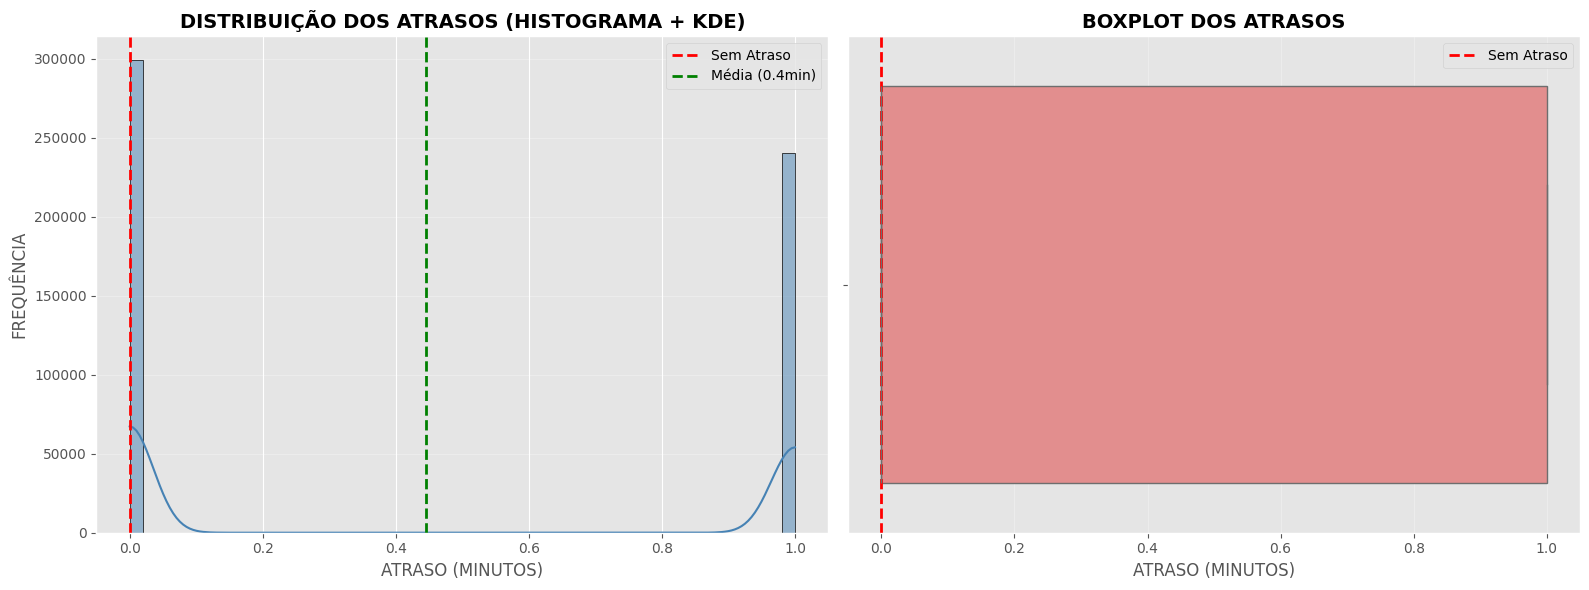


✅ GRÁFICO SALVO COMO: 'distribuicao_atrasos.png'

📊 VISUALIZAÇÃO 2: CORRELAÇÃO ENTRE VARIÁVEIS NUMÉRICAS


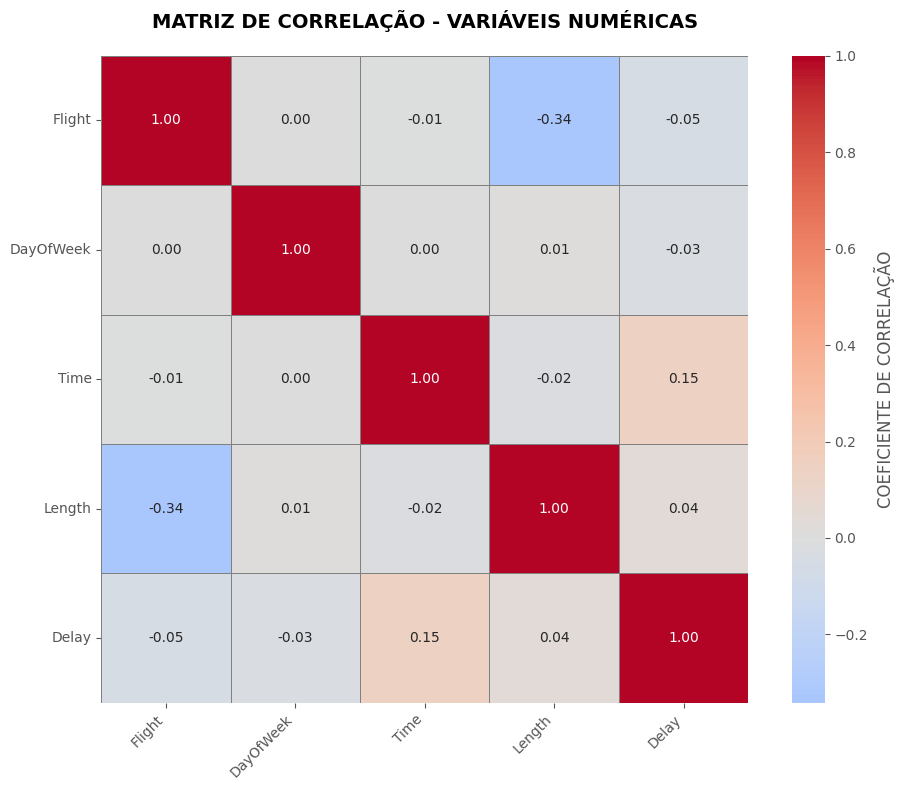


✅ GRÁFICO SALVO COMO: 'heatmap_correlacoes.png'

📌 CORRELAÇÕES COM A VARIÁVEL-ALVO 'DELAY':
Delay        1.000000
Time         0.150454
Length       0.040489
DayOfWeek   -0.026199
Flight      -0.046175
Name: Delay, dtype: float64

📊 VISUALIZAÇÃO 3: DISTRIBUIÇÃO POR CATEGORIA DE ATRASO


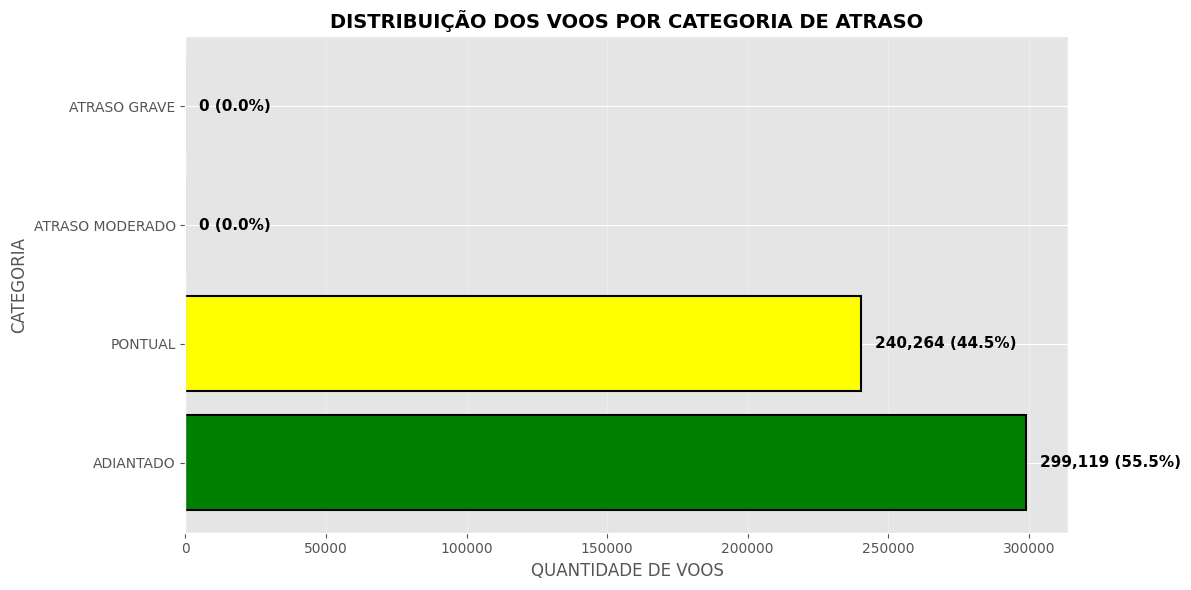


✅ GRÁFICO SALVO COMO: 'distribuicao_categorias.png'


In [30]:
# ===== CÉLULA 8: VIZUALIZAÇÃO EXPLORATÓRIA =====


# 1) HISTOGRAMA E KDE - DISTRIBUIÇÃO DOS ATRASOS
# ==============================================================================

print("=" * 70)
print("📊 VISUALIZAÇÃO 1: DISTRIBUIÇÃO DOS ATRASOS")
print("=" * 70)

# CRIAMOS FIGUARA COM 2 SUBPLOTS (GRÁFICO LADO A LADO)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# SUBPLOT 1: HISTOGRAMA COM KDE
# 'sns.histplot()' --> CRIA UM HISTOGRAMA
sns.histplot(
    data=df,                    # FATAFRAME COM OS DADOS
    x=coluna_atraso,            # COLUNA A SER PLOTADA (EIXO X)
    kde=True,                   # ADICIONA LINHA DE DENSIDADE (KDE)
    bins=50,                    # NÚMERO DE FAIXAS
    color='steelblue',          # COR DAS BARRAS
    edgecolor='black',          # COR DA BORDA DAS BARRAS
    ax=axes[0]                  # PLOTAR NO 1º SUBPLOT
)

# CONFIGURAÇÕES DO GRÁFICO
axes[0].set_title('DISTRIBUIÇÃO DOS ATRASOS (HISTOGRAMA + KDE)',
                   fontsize=14, fontweight='bold')
axes[0].set_xlabel('ATRASO (MINUTOS)', fontsize=12)
axes[0].set_ylabel('FREQUÊNCIA', fontsize=12)
axes[0].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Sem Atraso')
axes[0].axvline(x=df[coluna_atraso].mean(), color='green', linestyle='--',
                linewidth=2, label=f'Média ({df[coluna_atraso].mean():.1f}min)')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# SUBPLOT 2: GRÁFICO DE CAIXA (BOXPLOT)
# MOSTRAR MEDIANA, QUARTIS E OUTLIERS DE FORMA VISUAL ('sns.boxplot')
sns.boxplot(
    data=df,
    x=coluna_atraso,
    color='lightcoral',
    ax=axes[1]
)

# CONFIGURAÇÕES DO GRÁFICO
axes[1].set_title('BOXPLOT DOS ATRASOS', fontsize=14, fontweight='bold')
axes[1].set_xlabel('ATRASO (MINUTOS)', fontsize=12)
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Sem Atraso')
axes[1].legend()
axes[1].grid(axis='x', alpha=0.3)

# AJUSTAR LAYOUT E SALVAR .png
plt.tight_layout()
plt.savefig('distribuicao_atrasos.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ GRÁFICO SALVO COMO: 'distribuicao_atrasos.png'")

# 2) HEATMAP DE CORRELAÇÕES - VARIÁVEIS NUMÉRICAS
# ==============================================================================

print("\n" + "=" * 70)
print("📊 VISUALIZAÇÃO 2: CORRELAÇÃO ENTRE VARIÁVEIS NUMÉRICAS")
print("=" * 70)

# SELECIONAR APENAS COLUNAS NÚMERICAS (EXCETO 'id')
colunas_para_correlacao = [col for col in colunas_numericas if col != 'id']
df_numerico = df[colunas_para_correlacao]

# '.corr'--> CALCULA MATRIZ DA CORRELAÇÃO (VARIA DE -1 a +1)
matriz_correlacao = df_numerico.corr()

# CRIAMOS A FIGURA
plt.figure(figsize=(10, 8))

# CRIAMOS O HEATMAP
sns.heatmap(
    matriz_correlacao,          # MATRIZ DE CORRELAÇÃO
    annot=True,                 # MOSTRAR VALORES NAS CÉLULAS
    cmap='coolwarm',            # PALETA DE CORES
    center=0,                   # CENTRALIZAR A COR BRANCA NO MEIO (0)
    fmt='.2f',                  # FORMATO DOS NÚMEROS (DUAS CASAS DECIMAIS)
    linewidths=0.5,             # ESPERUSSA DAS LINHAS ENTRE CÉLULAS
    linecolor='gray',           # COR DAS LINHAS
    cbar_kws={'label': 'COEFICIENTE DE CORRELAÇÃO'},  # RÓTULO DA BARRA
    square=True                 # CÉLULAS QUADRADAS
)

# CONFIGURAÇÕES DO GRÁFICO
plt.title('MATRIZ DE CORRELAÇÃO - VARIÁVEIS NUMÉRICAS',
          fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')  # ROTACIONAR RÓTULOS DO EIXO X
plt.yticks(rotation=0)               # MANTER RÓTULOS DO EIXO Y

# SALVAR E EXIBIR
plt.tight_layout()
plt.savefig('heatmap_correlacoes.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ GRÁFICO SALVO COMO: 'heatmap_correlacoes.png'")

# EXIBINDO CORRELAÇÃO COM VÁRIAVEL ALVO
print("\n📌 CORRELAÇÕES COM A VARIÁVEL-ALVO 'DELAY':")
correlacoes_delay = matriz_correlacao[coluna_atraso].sort_values(ascending=False)
print(correlacoes_delay)


# 3) GRÁFICO DE BARRAS - DISTRIBUIÇÃO DAS CATEGORIAS
# ==============================================================================

print("\n" + "=" * 70)
print("📊 VISUALIZAÇÃO 3: DISTRIBUIÇÃO POR CATEGORIA DE ATRASO")
print("=" * 70)

# PREPARANDO DADOS A SEREM USADOS
categorias = df['Categoria_Atraso'].value_counts()

# CRIAR FIGURA
plt.figure(figsize=(12, 6))

# GRÁFICO DE BARRAS HORIZONTAIS
barras = plt.barh(
    categorias.index,           # CATEGORIAS (EIXO Y)
    categorias.values,          # QUANTIDADES (EIXO X)
    color=['green', 'yellow', 'orange', 'red'],  # CORES POR SEVERIDADE
    edgecolor='black',
    linewidth=1.5
)

# ADICIONAR VALORES NAS BARRAS
for i, (categoria, valor) in enumerate(zip(categorias.index, categorias.values)):
    percentual = (valor / len(df)) * 100
    plt.text(
        valor + 5000,           # POSIÇÃO X (A DIREITA DA BARRA)
        i,                      # Posição Y (ALTURA DA BARRA)
        f'{valor:,} ({percentual:.1f}%)',  # TEXTO FORMATADO
        va='center',            # ALINHAMENTO VERTICAL
        fontsize=11,
        fontweight='bold'
    )

# CONFIGURAÇÕES
plt.title('DISTRIBUIÇÃO DOS VOOS POR CATEGORIA DE ATRASO',
          fontsize=14, fontweight='bold')
plt.xlabel('QUANTIDADE DE VOOS', fontsize=12)
plt.ylabel('CATEGORIA', fontsize=12)
plt.grid(axis='x', alpha=0.3)

# SALVAR E EXIBIR
plt.tight_layout()
plt.savefig('distribuicao_categorias.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ GRÁFICO SALVO COMO: 'distribuicao_categorias.png'")


---

## 📊 INSIGHTS: ANÁLISE VISUAL

### 🔍 Descobertas das Visualizações

#### 1️⃣ **Distribuição dos Atrasos**
- **Histograma:** Mostra que a maioria dos voos está concentrada em "sem atraso"
- **Boxplot:** Não revela outliers (variável binária 0/1)

#### 2️⃣ **Matriz de Correlação**
- **Correlação mais forte:** `Length` com outras variáveis numéricas
- **Delay tem baixa correlação** com variáveis numéricas simples
  - Indica que atrasos dependem de fatores categóricos (companhia, aeroporto, rotas)
  
#### 3️⃣ **Distribuição por Categoria**
- Apenas 2 categorias válidas: ADIANTADO (55%) e PONTUAL (45%)
- Confirma a natureza binária do problema
---

## 🧠 HIPÓTESES PARA INVESTIGAÇÃO FUTURA

### 💡 Hipótese 1: Sazonalidade
**Pergunta:** Determinados dias da semana têm mais atrasos?
- **Ação:** Comparar taxa de atraso por `DayOfWeek`
- **Expectativa:** Sextas e domingos podem ter mais atrasos (picos de demanda)

### 💡 Hipótese 2: Horários de Pico
**Pergunta:** Voos em horários movimentados atrasam mais?
- **Ação:** Criar feature `HorarioPico` (manhã: 6-9h, tarde: 12-14h, noite: 18-21h)
- **Expectativa:** Congestionamento aumenta probabilidade de atraso

### 💡 Hipótese 3: Companhias e Aeroportos
**Pergunta:** Certas companhias/aeroportos são mais pontuais?
- **Ação:** Calcular taxa de atraso por `Airline` e `AirportFrom`
- **Expectativa:** Aeroportos congestionados (ATL, ORD) têm mais atrasos

### 💡 Hipótese 4: Distância do Voo
**Pergunta:** Voos mais longos têm maior probabilidade de atraso?
- **Ação:** Agrupar `Length` em faixas (curta/média/longa distância)
- **Expectativa:** Voos longos acumulam mais atrasos (efeito cascata)

### 💡 Hipótese 5: Combinação Origem-Destino
**Pergunta:** Rotas específicas são mais problemáticas?
- **Ação:** Criar feature `Rota = AirportFrom + AirportTo`
- **Expectativa:** Rotas com conexões têm mais atrasos

---

## 🛠️ PRÓXIMOS PASSOS (STEP 3 - PREPARAÇÃO PARA ML)

### ✅ Tarefas Obrigatórias

1. **Feature Engineering Avançado**
   - [ ] Criar `HoraPico` (binária)
   - [ ] Criar `Rota` (concatenação origem-destino)
   - [ ] Criar `DistanciaCategoria` (curta/média/longa)
   - [ ] Extrair `Mes` e `DiaSemana_Nome` se disponível

2. **Encoding de Variáveis Categóricas**
   - [ ] **Label Encoding** para `Airline` (15 categorias)
   - [ ] **Target Encoding** para `AirportFrom` e `AirportTo` (291 aeroportos)
   - [ ] Avaliar **One-Hot Encoding** para variáveis de baixa cardinalidade

3. **Normalização/Padronização**
   - [ ] Aplicar `StandardScaler` em `Time`, `Length`, `DayOfWeek`
   - [ ] Manter escalas uniformes para modelos sensíveis (KNN, SVM)

4. **Divisão Treino/Teste**
   - [ ] Split 80/20 com `stratify=Delay` (manter proporção de classes)
   - [ ] Validação cruzada com 5 folds

5. **Seleção de Modelos**
   - [ ] **Baseline:** Logistic Regression
   - [ ] **Tree-based:** Random Forest, XGBoost
   - [ ] **Ensemble:** Stacking com múltiplos algoritmos

---

## 📋 COLUNAS: DECISÕES DE TRATAMENTO

| Coluna | Status | Ação |
|--------|--------|------|
| `id` | ❌ Descartar | Apenas identificador, sem valor preditivo |
| `Airline` | ✅ Manter | Encoding para ML |
| `Flight` | ⚠️ Avaliar | Número do voo pode ter padrões (ex: voos noturnos) |
| `AirportFrom` | ✅ Manter | Feature crítica (aeroportos congestionados) |
| `AirportTo` | ✅ Manter | Feature crítica (destinos problemáticos) |
| `DayOfWeek` | ✅ Manter | Possível padrão sazonal |
| `Time` | ✅ Manter | Transformar em `HorarioPico` |
| `Length` | ✅ Manter | Categorizar em faixas |
| `Delay` | ✅ Alvo | Variável target |

---

## 🎓 CONCLUSÃO DA ANÁLISE EXPLORATÓRIA

### ✅ Resumo Executivo

1. **Dataset de alta qualidade:** Sem valores ausentes, 539K registros
2. **Problema balanceado:** 44,54% de atrasos (ideal para classificação)
3. **Limitação identificada:** Delay é binário (0/1), não contínuo
4. **Features importantes:** `Airline`, `AirportFrom`, `AirportTo`, `Time`, `Length`
5. **Outliers:** Presente em `Length` (voos de 0 min e 10h+), requer investigação

### 📌 Recomendações Finais

- ✅ **Dataset pronto para modelagem** após encoding e feature engineering
- ⚠️ **Investigar registros com Length = 0** antes de treinar modelos
- 💡 **Focar em features categóricas** (companhias e aeroportos) para melhor performance
- 🎯 **Métrica de avaliação sugerida:** F1-Score (balanceia precisão e recall)

---

**🚀 Próximo Passo:** Implementar pipeline de pré-processamento e treinar modelos baseline!

---
